## PRICE ELASTICITY MODEL

###Import Requird Library

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [36]:
#Load Dataset
PE = pd.read_csv("fitness_classes_EDA.csv")



In [37]:
PE

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Day,Hour,TimeSlot,Occupancy Rate,Revenue
0,BRP,20:20:20 9.30-10.30am,01-06-18,01-01-00 9:30,35,28,499,June,Friday,9,Morning,80.000000,13972
1,BRP,20:20:20 9.30-10.30am,08-06-18,01-01-00 9:30,35,35,499,June,Friday,9,Morning,100.000000,17465
2,BRP,20:20:20 9.30-10.30am,15-06-18,01-01-00 9:30,35,31,499,June,Friday,9,Morning,88.571429,15469
3,BRP,20:20:20 9.30-10.30am,22-06-18,01-01-00 9:30,35,32,499,June,Friday,9,Morning,91.428571,15968
4,BRP,20:20:20 9.30-10.30am,29-06-18,01-01-00 9:30,35,19,499,June,Friday,9,Morning,54.285714,9481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3284,NBL,Zumba Gold 12.45-1.45pm,01-05-18,01-01-00 12:45,60,47,1999,May,Tuesday,12,Afternoon,78.333333,93953
3285,NBL,Zumba Gold 12.45-1.45pm,08-05-18,01-01-00 12:45,60,42,1999,May,Tuesday,12,Afternoon,70.000000,83958
3286,NBL,Zumba Gold 12.45-1.45pm,15-05-18,01-01-00 12:45,60,38,1999,May,Tuesday,12,Afternoon,63.333333,75962
3287,NBL,Zumba Gold 12.45-1.45pm,22-05-18,01-01-00 12:45,60,39,1999,May,Tuesday,12,Afternoon,65.000000,77961


 Select Features and Target

In [38]:
#Target y
y = PE["Number Booked"]

In [39]:
#Feature x
x = PE[[
    "Price (INR)",
    "MaxBookees",
    "Hour",
    "TimeSlot",
    "Month",
    "Day",
    "ActivitySiteID",
    "ActivityDescription"
]]

In [40]:
#Check Missing Values
y.isnull().sum()

np.int64(0)

In [41]:
x.isnull().sum()

Price (INR)            0
MaxBookees             0
Hour                   0
TimeSlot               0
Month                  0
Day                    0
ActivitySiteID         0
ActivityDescription    0
dtype: int64

In [42]:

x.dtypes

Price (INR)            int64
MaxBookees             int64
Hour                   int64
TimeSlot                 str
Month                    str
Day                      str
ActivitySiteID           str
ActivityDescription      str
dtype: object

In [43]:
"""Categorical Feature Encoding
Categorical variables were transformed using One-Hot Encoding to convert text-based categories into numerical features suitable
 for regression modeling."""
X = pd.get_dummies(
    x,
    columns=[
        "TimeSlot",
        "Month",
        "Day",
        "ActivitySiteID",
        "ActivityDescription"
    ],
    drop_first=True
)

In [44]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [46]:
# Linear Regression
lr_model = LinearRegression()

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [47]:
# Train Models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Make Predictions

In [48]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [49]:
print(y_pred_lr[:10])
print(y_pred_rf[:10])

[ 8.31025139  7.8789688  29.75122758 26.97275456 21.37126844 22.12502043
 11.55996    13.19599785 30.37405962 22.2745384 ]
[ 7.10675     9.10879762 30.38367262 29.28508333 21.62735714 23.95432937
 16.38949405 13.31929762 25.76593452 25.69192857]


### Import Evaluation Metrics

In [50]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

In [51]:
### Calculate Model Performance

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("========================================")
print("LINEAR REGRESSION PERFORMANCE")
print("========================================")

print("R² Score :", round(r2_score(y_test, y_pred_lr), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred_lr), 4))

mse_lr = mean_squared_error(y_test, y_pred_lr)
print("MSE      :", round(mse_lr, 4))
print("RMSE     :", round(np.sqrt(mse_lr), 4))


print("\n========================================")
print("RANDOM FOREST PERFORMANCE")
print("========================================")

print("R² Score :", round(r2_score(y_test, y_pred_rf), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred_rf), 4))

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("MSE      :", round(mse_rf, 4))
print("RMSE     :", round(np.sqrt(mse_rf), 4))

LINEAR REGRESSION PERFORMANCE
R² Score : 0.7858
MAE      : 3.0405
MSE      : 19.2969
RMSE     : 4.3928

RANDOM FOREST PERFORMANCE
R² Score : 0.8235
MAE      : 2.9111
MSE      : 15.8969
RMSE     : 3.9871


### Model Comparison

In [53]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],

    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

comparison

,Model,R² Score,MAE,MSE,RMSE
0,Linear Regression,0.785762,3.040516,19.296942,4.392828
1,Random Forest,0.823509,2.911132,15.896946,3.987097


###Hyperparameter Tuning (Randomized Search CV)

In [54]:
from sklearn.model_selection import RandomizedSearchCV
# Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for m

In [55]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best Cross Validation Score:
0.8079993062110467


In [56]:
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

In [57]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Random Forest After Hyperparameter Tuning")

print("R² Score :", r2_score(y_test, y_pred_best))
print("MAE      :", mean_absolute_error(y_test, y_pred_best))
print("MSE      :", mean_squared_error(y_test, y_pred_best))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Random Forest After Hyperparameter Tuning
R² Score : 0.8293928863715488
MAE      : 2.8890155704646587
MSE      : 15.367005345197859
RMSE     : 3.920077211637273


In [58]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

top10

,Feature,Importance
1,MaxBookees,0.206964
2,Hour,0.086703
0,Price (INR),0.064952
183,ActivityDescription_Line Dance 10.45-11.45am,0.035053
16,ActivitySiteID_TSC,0.032313
3,TimeSlot_Evening,0.026687
4,TimeSlot_Morning,0.023167
11,Day_Tuesday,0.020864
5,Month_June,0.019787
14,ActivitySiteID_NBL,0.016813


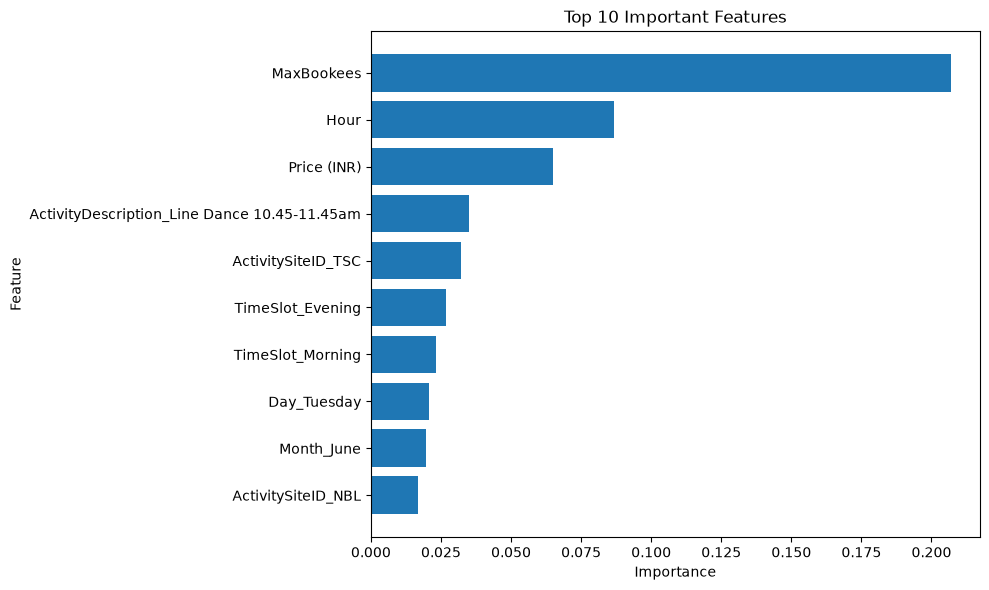

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Final Prediction Comparison

In [60]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best
})

comparison.head(10)

,Actual,Predicted
0,8,7.317289
1,13,8.640791
2,27,28.650287
3,27,26.667470
4,19,21.308428
5,22,23.148707
6,14,16.247984
7,11,14.010500
8,26,27.017725
9,26,25.341730


### Residual Plot

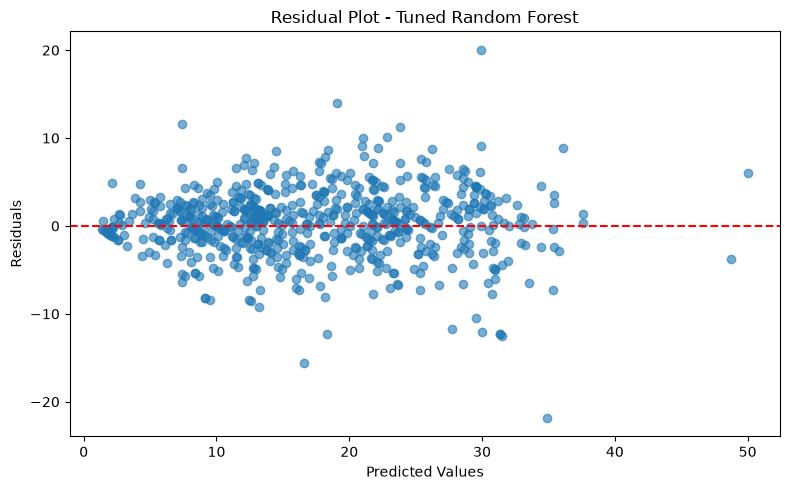

In [61]:
import matplotlib.pyplot as plt

# Calculate Residuals
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

plt.scatter(y_pred_best, residuals, alpha=0.6)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot - Tuned Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

### Actual vs Predicted Plot

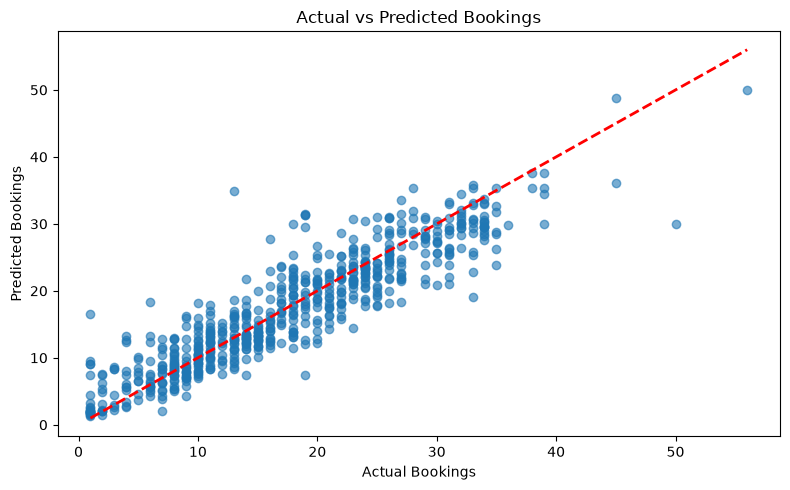

In [62]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_best, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("Actual vs Predicted Bookings")
plt.xlabel("Actual Bookings")
plt.ylabel("Predicted Bookings")

plt.tight_layout()

plt.show()

In [63]:
import joblib

# Save Best Random Forest Model
joblib.dump(best_rf, "best_rf_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
